# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.express as ex
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sbn
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 2. Load File

In [2]:
insurance_data = pd.read_csv("../input/insurance/insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. EDA Analysis

In [3]:
#Shape of the data
insurance_data.shape

(1338, 7)

In [4]:
#Statistics
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
#Pie chart for Sex
ex.pie(data_frame = insurance_data, names=insurance_data['sex'].unique(), values=insurance_data['sex'].value_counts(), color_discrete_sequence=ex.colors.sequential.RdBu, title='Pie chart for Sex')

In [6]:
#Pie chart for Smoker
ex.pie(data_frame = insurance_data, names=insurance_data['smoker'].unique(), values=insurance_data['smoker'].value_counts(), color_discrete_sequence=ex.colors.sequential.BuPu_r, title='Pie chart for Smoker')

In [7]:
#Pie chart for Region
ex.pie(data_frame = insurance_data, names=insurance_data['region'].unique(), values=insurance_data['region'].value_counts(), color_discrete_sequence=ex.colors.sequential.Blues_r, title='Pie chart for Region')

In [8]:
#Bar chart for number of Children
ex.bar(data_frame = insurance_data, x=insurance_data['children'].unique(), y=insurance_data['children'].value_counts(), color_discrete_sequence=ex.colors.sequential.Cividis_r, title='Bar chart for number of Children')

In [9]:
#Spread of BMI based on Region Level and Sex
fig = ex.box(data_frame = insurance_data, x="region", y="bmi", color="sex", title='Spread of BMI based on Region Level and Sex')
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [10]:
#Spread of BMI based on number of children and Sex
fig = ex.box(data_frame = insurance_data, x="children", y="bmi", color="sex", title='Spread of BMI based on Sex and # of Children')
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [11]:
#Spread of BMI based on Region Level and Smoker
color_discrete_map = {'yes': 'rgb(255,0,0)', 'no': 'rgb(0,255,0)'}
fig = ex.box(data_frame = insurance_data, x="region", y="bmi", color="smoker", title='Spread of BMI based on Region Level and Smoker', color_discrete_map=color_discrete_map)
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [12]:
#Spread of BMI based on Smoker and # of Children
color_discrete_map = {'yes': 'rgb(255,0,0)', 'no': 'rgb(0,255,0)'}
fig = ex.box(data_frame = insurance_data, x="children", y="bmi", color="smoker", title='Spread of BMI based on Smoker and # of Children', color_discrete_map=color_discrete_map)
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [13]:
#Spread of Individual Medical Costs based on Sex and # of Children
fig = ex.box(data_frame = insurance_data, x="children", y="charges", color="sex", title='Spread of Individual Medical Costs based on Sex and # of Children')
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [14]:
#Spread of Individual Medical Costs based on Region Level and Sex
fig = ex.box(data_frame = insurance_data, x="region", y="charges", color="sex", title='Spread of Individual Medical Costs based on Region Level and Sex')
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [15]:
#Spread of Individual Medical Costs based on Region Level and Smoker
color_discrete_map = {'yes': 'rgb(255,0,0)', 'no': 'rgb(0,255,0)'}
fig = ex.box(data_frame = insurance_data, x="region", y="charges", color="smoker", title='Spread of Individual Medical Costs based on Region Level and Smoker', color_discrete_map = color_discrete_map)
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [16]:
#Spread of Individual Medical Costs based on # of Children and Smoker
color_discrete_map = {'yes': 'rgb(255,0,0)', 'no': 'rgb(0,255,0)'}
fig = ex.box(data_frame = insurance_data, x="children", y="charges", color="smoker", title='Spread of Individual Medical Costs based on # of Children and Smoker', color_discrete_map = color_discrete_map)
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [17]:
#scatter plot - bmi vs charges based on sex
ex.scatter(data_frame=insurance_data, x='bmi', y='charges', color = 'sex', title = 'BMI vs Individual Medical Costs based on sex')

In [18]:
#scatter plot - bmi vs charges based on smoker
color_discrete_map = {'yes': 'rgb(220,158,130)', 'no': 'rgb(130,220,150)'}
ex.scatter(data_frame=insurance_data, x='bmi', y='charges', color = 'smoker', title = 'BMI vs Individual Medical Costs based on smoker', color_discrete_map = color_discrete_map)

In [19]:
#scatter plot - bmi vs charges based on region
color_discrete_map = {'southwest': 'rgb(220,158,130)', 'southeast': 'rgb(130,20,250)', 'northeast': 'rgb(100,250,70)', 'northwest': 'rgb(70,60,100)'}
ex.scatter(data_frame=insurance_data, x='bmi', y='charges', color = 'region', title = 'BMI vs Individual Medical Costs based on region', color_discrete_map = color_discrete_map)

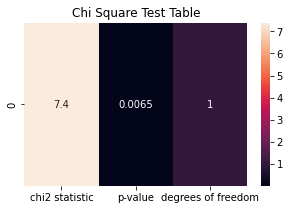

In [20]:
#Chi Sqaure Test
ct_table_ind=pd.crosstab(insurance_data['sex'],insurance_data['smoker'])
chi2_stat, p, dof, _ = chi2_contingency(ct_table_ind)
ct_dataframe = pd.DataFrame()
ct_dataframe['chi2 statistic']=pd.Series(chi2_stat)
ct_dataframe['p-value']=pd.Series(p)
ct_dataframe['degrees of freedom']=pd.Series(dof)
plt.figure(figsize = (5, 3))
sbn.heatmap(ct_dataframe, annot = True)
plt.title('Chi Square Test Table')
plt.show()

In [21]:
print("The critical value for the chi-square test with a degree of freedom of 1 and alpha 0.05 is 3.841. Since the test statistic (7.4) exceeds the critical value the null hypothesis is rejected. Therefore, gender and smoking a significant variation in the distribution. This could be concluded that there is a substantial dependency of gender on smoking according to the data.")

The critical value for the chi-square test with a degree of freedom of 1 and alpha 0.05 is 3.841. Since the test statistic (7.4) exceeds the critical value the null hypothesis is rejected. Therefore, gender and smoking a significant variation in the distribution. This could be concluded that there is a substantial dependency of gender on smoking according to the data.


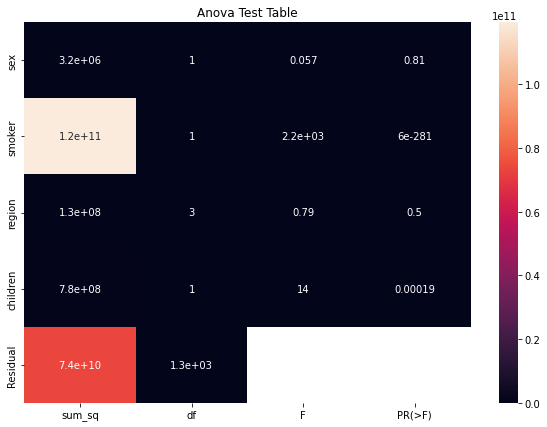

In [22]:
#Anova Test
model = ols('charges ~ sex + children + smoker + region', data = insurance_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
plt.figure(figsize = (10, 7))
sbn.heatmap(anova_table, annot = True)
plt.title('Anova Test Table')
plt.show()

In [23]:
print('smoker and # of children have imapct on the Individual medical costs')

smoker and # of children have imapct on the Individual medical costs


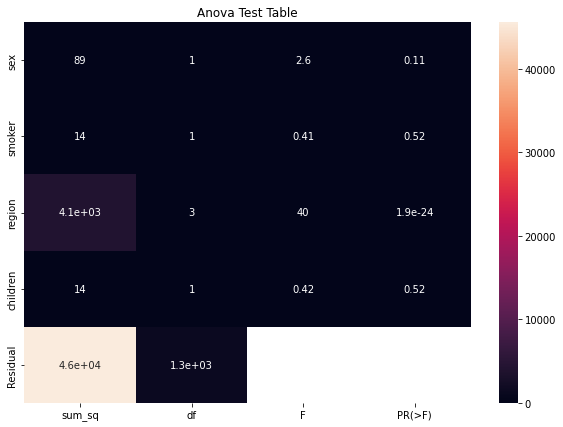

In [24]:
#Anova Test
model = ols('bmi ~ sex + children + smoker + region', data = insurance_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
plt.figure(figsize = (10, 7))
sbn.heatmap(anova_table, annot = True)
plt.title('Anova Test Table')
plt.show()

In [25]:
print('region has imapct on the Individual medical costs')

region has imapct on the Individual medical costs


Checking skewness
age  :  0.05567251565299186
bmi  :  0.2840471105987448
charges  :  1.5158796580240388


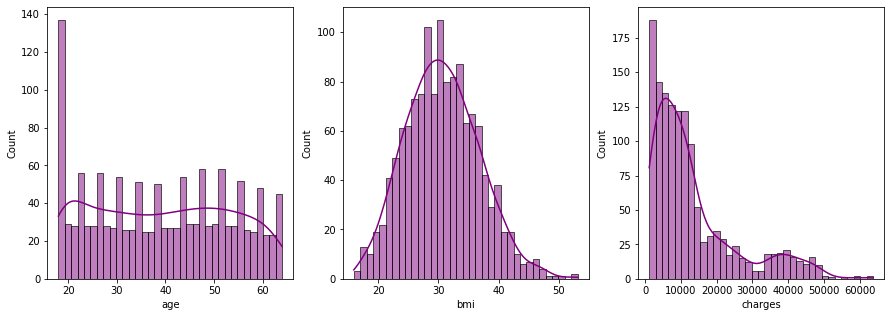

In [26]:
#Checking distribution of Data
columns = ['age', 'bmi', 'charges']
q, r = divmod(len(columns), 3)
fig, ax = plt.subplots(q, 3, figsize=(15,5))
print("Checking skewness")
for i, col in enumerate(columns):
    print(col, ' : ', insurance_data[col].skew())
    q, r = divmod(i, 3)
    sbn.histplot(insurance_data[col], kde=True, ax=ax[r], bins = 35, color='purple')

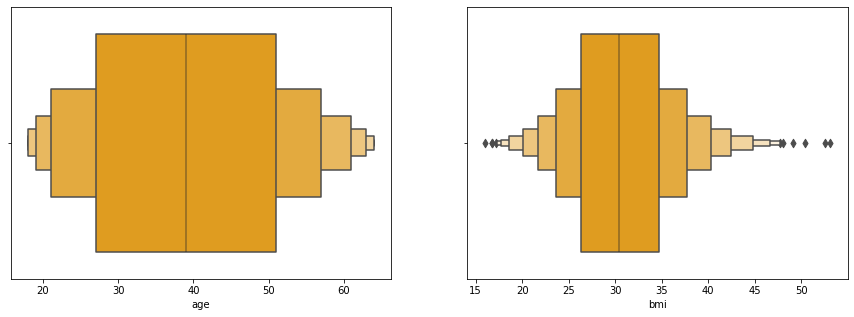

In [27]:
#Box Plot - Checking Outliers
columns = ['age', 'bmi']
q, r = divmod(len(columns), 2)
fig, ax = plt.subplots(q, 2, figsize=(15,5))
for i, col in enumerate(columns):
    q, r = divmod(i, 2)
    warnings.filterwarnings(action='ignore')
    sbn.boxenplot(insurance_data[col], ax=ax[r], color='orange')

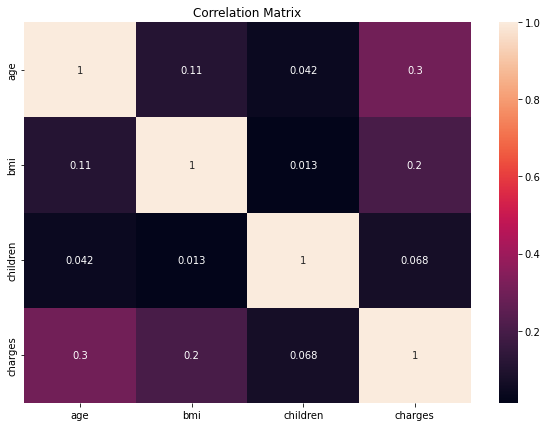

In [28]:
#Correlation Analysis
plt.figure(figsize = (10, 7))
sbn.heatmap(insurance_data.corr(), annot = True)
plt.title('Correlation Matrix')
plt.show()

In [29]:
#Checking Missing Values
insurance_data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 4. Data Preprocessing

In [30]:
#Removing Duplicates
insurance_data.drop_duplicates(inplace=True)
insurance_data.shape

(1337, 7)

In [31]:
#One Hot Encoding
insurance_data = pd.get_dummies(insurance_data, columns = ['sex', 'smoker', 'region'], drop_first=True)

In [32]:
insurance_data.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [33]:
#Features and Target
features = insurance_data.drop(['charges'], axis=1)
target = insurance_data['charges']

In [34]:
#Train Test Split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=10)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1002, 8), (335, 8), (1002,), (335,))

In [35]:
#Feature Scaling and Feature Transformation
standard_scaler = StandardScaler().fit(x_train)
x_train_trans = standard_scaler.transform(x_train)
x_test_trans = standard_scaler.transform(x_test)
y_train_trans = np.log(y_train)
y_test_trans = np.log(y_test)

# 5. Model Selection

In [36]:
#i. Linear Models
model_factory = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]
for model in model_factory:
    scores = cross_val_score(model, x_train_trans, y_train_trans, cv=KFold(n_splits=10), scoring='r2')
    print(model.__class__.__name__, " : ", np.mean(scores))

LinearRegression  :  0.7633167599645234
Ridge  :  0.7633341662993804
Lasso  :  -0.01341871099376184
ElasticNet  :  0.10245215761424942


In [37]:
#ii. Other Models
model_factory = [SVR(), KNeighborsRegressor()]
for model in model_factory:
    scores = cross_val_score(model, x_train_trans, y_train, cv=KFold(n_splits=10), scoring='r2')
    print(model.__class__.__name__, " : ", np.mean(scores))

SVR  :  -0.11327349602034369
KNeighborsRegressor  :  0.7893408874171747


In [38]:
#iii. Tree Based Models
model_factory = [DecisionTreeRegressor(), RandomForestRegressor(), BaggingRegressor(), AdaBoostRegressor(),XGBRegressor(), LGBMRegressor()]
for model in model_factory:
    scores = cross_val_score(model, x_train, y_train, cv=KFold(n_splits=10), scoring='r2')
    print(model.__class__.__name__, " : ", np.mean(scores))

DecisionTreeRegressor  :  0.7172373451981204
RandomForestRegressor  :  0.8453199969980165
BaggingRegressor  :  0.8271824636700336
AdaBoostRegressor  :  0.8225927287730117
XGBRegressor  :  0.8266434897149807
LGBMRegressor  :  0.8461643441094815


In [39]:
print("Based on Cross Val Score, I am Selecting LGBMRegressor")

Based on Cross Val Score, I am Selecting LGBMRegressor


# 6. Feature Selection

Selected Features :  Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


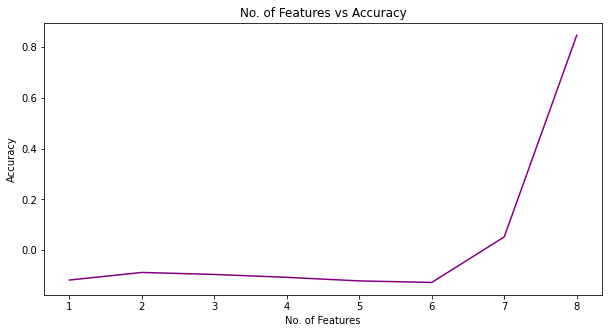

In [40]:
rfecv = RFECV(LGBMRegressor(), cv=KFold(n_splits=10), scoring='r2')
rfecv.fit(x_train, y_train)
print("Selected Features : ", x_train.columns[rfecv.support_])
plt.figure(figsize=(10,5))
plt.plot(range(1, len(rfecv.grid_scores_)+1), np.mean(rfecv.grid_scores_, axis=1), color='purple')
plt.xlabel("No. of Features")
plt.ylabel("Accuracy")
plt.title("No. of Features vs Accuracy")
plt.show()

# 7. HyperParameter Tuning

In [41]:
params = {'min_data_in_leaf':[20, 30, 70, 90], 'max_depth': [6, 9, 12, 15], 'n_estimators':[50, 100, 200]}
gs = GridSearchCV(LGBMRegressor(), param_grid=params, cv=KFold(n_splits=10), scoring='r2', n_jobs=-1)
gs.fit(x_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min

GridSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=False),
             estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'max_depth': [6, 9, 12, 15],
                         'min_data_in_leaf': [20, 30, 70, 90],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [42]:
#Best Estimator
gs.best_estimator_

LGBMRegressor(max_depth=6, min_data_in_leaf=70)

In [43]:
#Best Score
gs.best_score_

0.8639387933615733

# 8. Model Building and Training

In [44]:
#Selecting Ridge Model
lgbm_tuned_model = gs.best_estimator_.fit(x_train, y_train)

# 9. Model Evaluation

In [45]:
#Training and Testing Accuracy
train_pred = lgbm_tuned_model.predict(x_train)
test_pred = lgbm_tuned_model.predict(x_test)
train_r2_score = r2_score(y_train, train_pred)
test_r2_score = r2_score(y_test, test_pred)
train_Adj_r2 = 1 - (1-train_r2_score) * (len(y_train)-1)/(len(y_train)-x_train.shape[1]-1)
test_Adj_r2 = 1 - (1-test_r2_score) * (len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print("Training r2_score : ", train_r2_score, "Training Adj. r2_score : ", train_Adj_r2)
print("Testing r2_score : ", test_r2_score, "Testing Adj. r2_score : ", test_Adj_r2)

Training r2_score :  0.8976102461241072 Training Adj. r2_score :  0.8967853538471615
Testing r2_score :  0.82668809657492 Testing Adj. r2_score :  0.8224350437301328
